<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/35_Mini_project/Clustering_Antarctic_Penguin_Species.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Description**  
Delve into the information about penguins by utilizing unsupervised learning techniques on a thoughtfully curated dataset. uncover concealed patterns, clusters, and relationships that exist within the dataset.

Unfortunately, they have not been able to record the species of penguin, but they know that there are at least three species that are native to the region: Adelie, Chinstrap, and Gentoo. Your task is to apply your data science skills to help them identify groups in the dataset!

**Utilize your unsupervised learning skills to clusters in the penguins dataset!**

- Import, investigate and pre-process the "penguins.csv" dataset.
- Perform a cluster analysis based on a reasonable number of clusters and collect the average values for the clusters. The output should be a DataFrame named stat_penguins with one row per cluster that shows the mean of the original variables (or columns in "penguins.csv") by cluster. stat_penguins should not include any non-numeric columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB


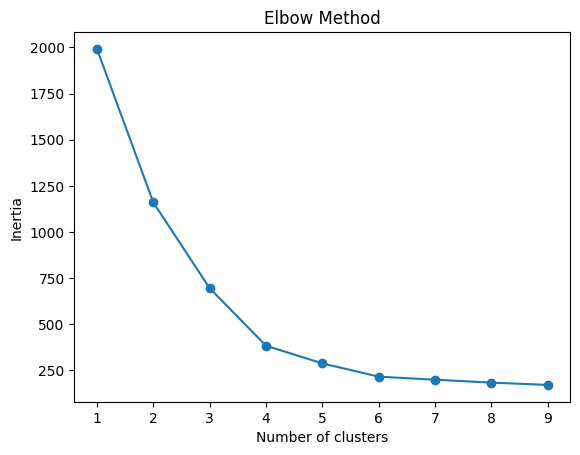

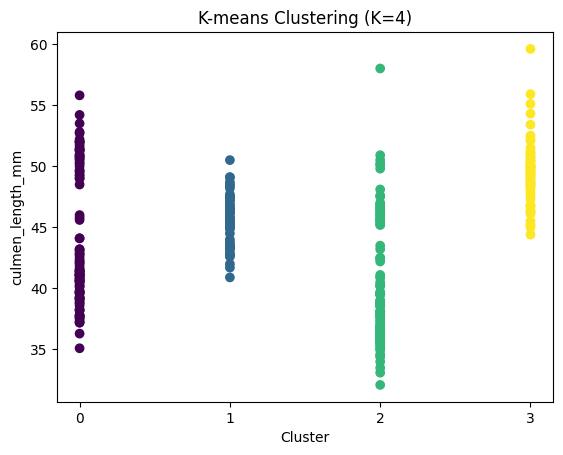

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE
label,,,,,,
0,43.878302,19.111321,194.764151,4006.603774,0.0,1.0
1,45.563793,14.237931,212.706897,4679.741379,1.0,0.0
2,40.217757,17.611215,189.046729,3419.158879,1.0,0.0
3,49.473770,15.718033,221.540984,5484.836066,0.0,1.0


In [2]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1 - Loading and examining the dataset
# Corrected URL to the raw CSV data
penguins_df = pd.read_csv("https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/35_Mini_project/Dataset/penguins.csv")
penguins_df.head()
penguins_df.info()

# Step 2 - Perform preprocessing steps on the dataset to create dummy variables
# Convert categorical variables into dummy/indicator variables
penguins_df = pd.get_dummies(penguins_df, dtype='int') # dtype='int' ensure the output will be 0/1 instead of True/False


# Step 3 - Perform preprocessing steps on the dataset - standarizing/scaling
# Scaling variables (also called standardizing) is recommended before performing a clustering algorithm since this can increase the performance greatly (see https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html)
scaler = StandardScaler()
X = scaler.fit_transform(penguins_df)
penguins_preprocessed = pd.DataFrame(data=X,columns=penguins_df.columns)
penguins_preprocessed.head(10)

# Step 4 - Detect the optimal number of clusters for k-means clustering
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(penguins_preprocessed) # Added n_init=10
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()
n_clusters=4

# Step 5 - Run the k-means clustering algorithm
# with the optimal number of clusters

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(penguins_preprocessed) # Added n_init=10
penguins_df['label'] = kmeans.labels_

# and visualize the clusters (here for the 'culmen_length_mm' column)
plt.scatter(penguins_df['label'], penguins_df['culmen_length_mm'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('Cluster')
plt.ylabel('culmen_length_mm')
plt.xticks(range(int(penguins_df['label'].min()), int(penguins_df['label'].max()) + 1))
plt.title(f'K-means Clustering (K={n_clusters})')
plt.show()

# Step - create final `stat_penguins` DataFrame
# Exclude non-numeric columns before calculating the mean
numeric_columns = penguins_df.select_dtypes(include='number').columns.tolist()
stat_penguins = penguins_df[numeric_columns].groupby('label').mean()
stat_penguins